# Use Lasso Regression Model for training

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns

In [13]:
df=pd.read_csv("insurance.csv")

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [14]:
x=df.drop(["charges"],axis=1)
y=df["charges"]

# encoding
x["sex"]=x["sex"].map({"female" : 1 ,"male": 0})
x["smoker"]=x["smoker"].map({"yes" : 1 ,"no": 0})

# x=pd.get_dummies(x, columns=["region"],drop_first=False,dtype=int)
x=pd.get_dummies(x, columns=["region"],drop_first=True,dtype=int)

In [15]:
x["age_smoker"]=x["age"] * x["smoker"]
x["bmi_smoker"]=x["bmi"] * x["smoker"]

In [6]:
# test and training
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.2, 
    random_state=42)

In [7]:
# Train the mode
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
# predict values
y_predict=model.predict(x_test)

In [9]:
y_predict

array([11244.92252985,  7419.09613036, 33108.56263345, 10825.70349972,
       28165.83120369,  6492.30055169,  2795.33432583, 14417.81581562,
        5687.02991028, 11674.71358693, 20657.59012262,  9146.41694187,
        5695.47866425, 51922.27364821, 52110.34418673, 46640.17211168,
       11685.28405314, 43258.65742309, 10134.76643993, 27544.17451838,
        5590.71503071,  9112.26016698,  1829.43896788,  4568.33364842,
       12451.66624573, 12838.44659475, 13233.15939348,  6449.57806469,
       11799.9498717 ,  1825.10642493,  9707.98622109, 12978.53418336,
        3236.11758774,  7025.39527005,  4125.34618621, 10091.32699237,
        3262.60876705,  9119.59871467, 26284.74334712, 37686.43163646,
        4634.27512745,  3702.06635756, 12658.69778308, 12849.08764218,
        6810.63583482, 12752.76878332,  4474.37122331,  5198.08817694,
       41615.58170738,  6338.51473147, 14310.53229154,  2272.59249937,
        9166.71958047,  2711.80386028, 11905.92268657, 12175.67773632,
      

In [10]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
Laso_model=Lasso(alpha=0.5)
Laso_model.fit(x_train,y_train)
y_predict=Laso_model.predict(x_test)
mse=mean_squared_error(y_test,y_predict)
print(mse)

20918648.889825605


mse for alpha=0.001:  20922599.87103596
mse for alpha=0.1:  20921803.698431373
mse for alpha=1:  20914832.63508914
mse for alpha=2:  20908106.77995452
mse for alpha=5:  20890881.000633497
mse for alpha=10:  20872844.794796687
mse for alpha=20:  20877828.532378826
mse for alpha=30:  20937537.133939773
mse for alpha=40:  21046489.29389078
mse for alpha=50:  21196929.86960891
mse for alpha=100:  22423172.686023246


<Axes: >

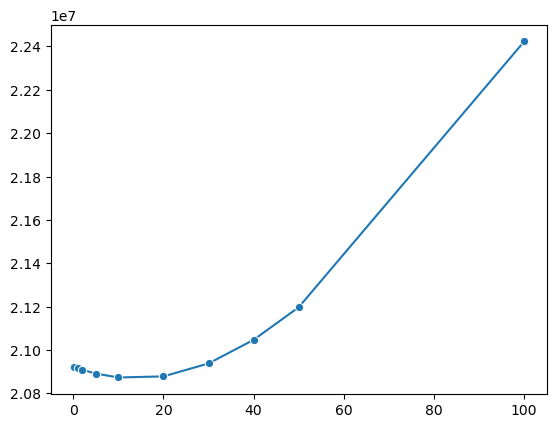

In [17]:
alphas=[0.001,0.1,1,2,5,10,20,30,40,50,100]
mses=[]
for a in alphas:
    Laso_model=Lasso(alpha=a)
    Laso_model.fit(x_train,y_train)
    y_predict=Laso_model.predict(x_test)
    mse=mean_squared_error(y_test,y_predict)
    print(f"mse for alpha={a}: ", mse)
    mses.append(mse)
sns.lineplot(x=alphas,y=mses,marker="o")